In [1]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt # for making figures 
%matplotlib inline

In [2]:
# read in all the words 
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words 
import random 
random.seed(42)
random.shuffle(words)

In [17]:
# build the dataset 
block_size = 8 # context length : how many characters do we take to predict the next one ?

def build_dataset(words):
    X,Y =[],[]
    for w in words:
        context = [0]*block_size
        for ch in w +".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] #crop and append 

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2])  #10%
Xte, Yte = build_dataset(words[n2:]) #10%


torch.Size([182437, 8]) torch.Size([182437])
torch.Size([22781, 8]) torch.Size([22781])
torch.Size([22928, 8]) torch.Size([22928])


In [18]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x ), '--->', itos[y.item()])

........ ---> t
.......t ---> a
......ta ---> u
.....tau ---> r
....taur ---> e
...taure ---> n
..tauren ---> .
........ ---> s
.......s ---> u
......su ---> l
.....sul ---> e
....sule ---> m
...sulem ---> a
..sulema ---> n
.suleman ---> .
........ ---> z
.......z ---> e
......ze ---> r
.....zer ---> e
....zere ---> n


In [47]:
# near copy of the layers we have developed in part 3

#-------------------------------------------------------------------------------------------------------------

class Linear:

    def __init__(self,fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None 

    def __call__(self,x): 
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

#---------------------------------------------------------------------------------------------------------

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # parameters (trained with a running "momentum update")
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self,x):
        # calculate the forward pass
        if self.training:
            if x.ndim ==2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim,keepdim=True) # batch mean
            xvar = x.var(dim,keepdim=True, unbiased=False) #batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers 
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1- self.momentum) * self.running_var + self.momentum *  xvar
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

#---------------------------------------------------------------------------------------------------------------------

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

#----------------------------------------------------------------------------------------------------------------------
class Embedding:
    def __init__(self,num_embedding,embedding_dim):
        self.weight = torch.randn((num_embedding,embedding_dim))
    def __call__(self , IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

#----------------------------------------------------------------------------------------------------------------------
class FlattenConsecutive :
    def __init__(self,n):
        self.n = n

    def __call__(self,x):
        B,T,C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

#------------------------------------------------------------------------------------------------------------
class Sequential:
    def __init__(self,layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # get parameters of all layers and stretch them out into one list
        return [p for layer in self.layers for p in layer.parameters()]
    


In [48]:
torch.manual_seed(42);

In [62]:
n_embd = 24 # the dimensionality of the character embedding vectors 
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
      
    Linear(n_hidden  ,  vocab_size),
])

with torch.no_grad():
    # last layer: make less confident
    model.layers[-1].weight +=0.1
   

parameters = model.parameters()
print(sum(p.nelement() for p in parameters )) # number of parameters in total
for p in parameters:
    p.requires_grad =True

76579


In [65]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [66]:
e = torch.randn(32,4,68)
emean = e.mean((0,1),keepdim=True)
evar = e.var((0,1),keepdim=True)
ehat = (e-emean) / torch.sqrt(evar + 1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [67]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 128])

In [64]:
ix = torch.randint(0, Xtr.shape[0],(4,)) #lets look at the batch of just 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  3, 15],
        [ 0, 20, 15, 18, 18,  5, 14,  3],
        [ 0,  0,  0,  1, 13,  1, 18, 25],
        [ 0,  0,  0,  0,  0, 20,  9,  1]])

In [68]:
for layer in model.layers:
    print(layer.__class__.__name__, ':' , tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [70]:
model.layers[0].out.shape

torch.Size([4, 8, 24])

In [71]:
model.layers[1].out.shape

torch.Size([4, 4, 48])

In [72]:
model.layers[2].out.shape
# what happens is this 
# torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 4, 128])

In [73]:
# we want 4,4,20 not 4,80 now so we wii change Flatten
# in list we know list(range(10))[::2] gives us all even now
e = torch.randn(4,8,10)
explicit = torch.cat([e[:, ::2,:], e[:,1::2,:]], dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [74]:
(e.view(4,4,20) == explicit).all()

tensor(True)

In [75]:
# same optimization as last time 
max_steps = 200000
batch_size = 32
lossi =[]
ud = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix],Ytr[ix] # batch X,Y

    #forward pass 
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function 

    # backward pass 
    for p in parameters:
        p.grad = None 
    loss.backward()

    #update  SGD
    lr = 0.1 if i < 100000 else 0.01 #step learning rate decay
    for p in parameters:
        p.data += -lr *p.grad

    # track stats 
    if i % 10000 ==0: # print every once in a while 
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    lossi.append(loss.log10().item())
    



      0/ 200000:3.5198
  10000/ 200000:2.4533
  20000/ 200000:1.9338
  30000/ 200000:1.8894
  40000/ 200000:1.9579
  50000/ 200000:1.8830
  60000/ 200000:1.8401
  70000/ 200000:2.1012
  80000/ 200000:1.5457
  90000/ 200000:2.2067
 100000/ 200000:1.7161
 110000/ 200000:2.0798
 120000/ 200000:2.2972
 130000/ 200000:1.9101
 140000/ 200000:1.8447
 150000/ 200000:1.6392
 160000/ 200000:1.9404
 170000/ 200000:1.7871
 180000/ 200000:1.8591
 190000/ 200000:1.6823


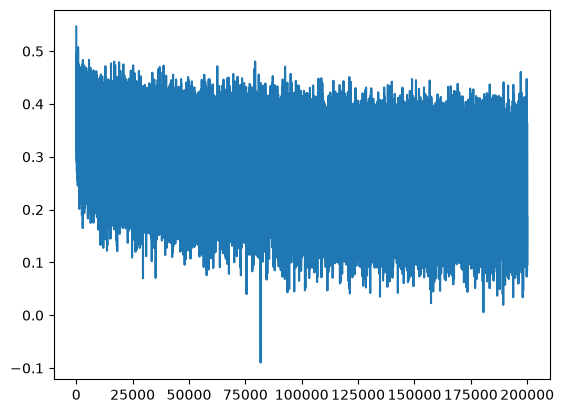

In [76]:
plt.plot(lossi)

In [78]:
# plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [79]:
torch.arange(10).view(-1,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [80]:
for layer in model.layers:
    layer.training = False

In [81]:
@torch.no_grad() #this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        "train":(Xtr,Ytr),
        "val":(Xdev, Ydev),
        "test":(Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 1.788164496421814
val 1.9988406896591187


In [82]:
# sample  from the model

for _ in range(20):
    out =[]
    context = [0] * block_size # initialize with all .....
    while True:
        # forward pass the neural net 
        logits = model(torch.tensor([context]))  
        probs = F.softmax(logits , dim=1)
        #sample from the distribution \
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples 
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special "." token , break 
        if ix == 0:
            break

    print("".join(itos[i] for i in out )) # decode and print the generated word 


aliyany.
chayden.
abellame.
isaan.
thepton.
ayain.
angely.
dmarcei.
kacei.
rebette.
chane.
katej.
aaron.
eyaoe.
draysen.
rachelse.
shrihaise.
rebena.
mykari.
letian.
